In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
# Pipeline:
#  Define a neural net
#  Create a dataset to train on. Standard classifier example, or maybe XOR (or both)
#  Create a function script which enables either Cross-entropy or Direction loss function [ESSENTIAL]
#  Training model on the dataset on set of training points (very few -> 100% accuracy) [ESSENTIAL]

## Standard libraries
import numpy as np
import pickle
import yaml

## Progress bar
from tqdm.auto import tqdm

#ML Libraries
import jax
import optax

import os

import torch.utils.data as data

# Custom Libraries
from counterfactual_alignment.custom_models   import SimpleClassifier, SimpleClassifier_v2, MLP, CNN,  GSPaper, GSPaperNew, GSPaper2, GSPaper3, BagOfWordsClassifier, BagOfWordsClassifierSimple, BagOfWordsClassifierSingle
from counterfactual_alignment.custom_datasets import customDataset, genCustomDataset
from counterfactual_alignment.custom_models import custom_models
from counterfactual_alignment.custom_datasets import datasets as custom_datasets
from counterfactual_alignment.loss_functions import loss_functions
from counterfactual_alignment.knowledge_functions import knowledge_functions
import  counterfactual_alignment.utilities  as ut
from scipy.stats import multivariate_normal as mvn
import torch
import jax.numpy as jnp


from torch import normal
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import numpy as np
from scipy.stats import multivariate_normal as mvn

import jax
import jax.numpy as jnp
import optax
from flax.training import train_state
from flax import traverse_util
import flax
from flax import linen as nn

from tqdm.auto import tqdm

import random
import seaborn as sns
import sys
## Imports for plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib import colormaps

import time
import math
import subprocess
import glob
import os
import json
import csv
from pathlib import Path
from functools import partial

import counterfactual_alignment.custom_models as cm
from counterfactual_alignment.custom_models import custom_models

from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D

# FAT Forensics Counterfactual Explainer
import fatf.transparency.predictions.counterfactuals as fatf_cf

from scipy.sparse import hstack, vstack

# import tensorflow as tf
import pickle



In [27]:
def predict_wrapper(params, model, x, rng):
    """
    Wrapper for model prediction that works with multi-class outputs.
    
    Args:
        params: model parameters
        model: Flax model
        x: single input or batch of inputs, shape (2,) or (batch_size, 2)
        rng: PRNG key for dropout / stochastic layers
    
    Returns:
        logits: raw model outputs (num_classes,)
    """
    # Ensure x has a batch dimension
    x = jnp.atleast_2d(x)  # shape (1, 2) if single input
    
    logits, _ = model.apply(
        {'params': params},
        x,
        train=True,
        rngs={'dropout': rng}
    )
    
    # # logits shape = (batch_size, num_classes)
    # # If batch_size = 1, squeeze batch axis but keep class axis
    if logits.shape[0] == 1:
        logits = logits.squeeze(axis=0)
    # else:        
    #     logits = np.array([lgts[i]for lgts, i in zip(logits, Y)])

    
    return logits



def close_event():
            plt.close() #timer calls this function after 3 seconds and closes the window 


def single_input_loss_wrt_x(params, model, x, y, rng):
    """
    Scalar loss w.r.t input x for a single sample
    """
    logits = predict_wrapper(params, model, x, rng)  # shape: (num_classes,)
    # Compute cross-entropy with the true label
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=jnp.expand_dims(logits, axis=0),  # (1, num_classes)
        labels=jnp.array([y])
    ).mean()
    return loss

In [28]:
num_classes = 3

class Gaussian():
    def __init__(self, rng, size, num_classes=2):
        """
        Inputs  | rng   : Pseudo-random number generator
                | size  : Size of dataset
        Outputs | X     : X,Y cooridnates of observations
                | Y     : Class label ([0,1...n])
                | K     : Knowledge - empty dict, for storing directional info
        """
        self.num_classes = num_classes
        # Spread means around a circle for separation
        angles = np.linspace(0, 2*np.pi, num_classes, endpoint=False)
        self.class_means = [[np.cos(a)*3, np.sin(a)*3] for a in angles]

        # Identity covariance for each class (can customize)
        self.covariances = [np.eye(2) for _ in range(num_classes)]

        # Split dataset size evenly across classes
        base     = size // self.num_classes
        leftover = size %  self.num_classes
        class_sizes = [base + (1 if i < leftover else 0) for i in range(self.num_classes)]

        # Generate data for each class
        self.X = np.concatenate([
            rng.multivariate_normal(np.array(self.class_means[i]),
                                    self.covariances[i],
                                    class_sizes[i])
            for i in range(self.num_classes)
        ])
        self.Y = np.concatenate([[i]*class_sizes[i] for i in range(self.num_classes)])

        self.K = {}  # placeholder knowledge structure


    def optimum_classifier(self, z, probabilities=True):
        """
        Inputs  | z:      (N,2) array of coordinates to classify
        Outputs | probs:  array of probabilities for each class for input data
        """
        pdfs = []
        for i in range(self.num_classes):
            pdfs.append(mvn.pdf(z, self.class_means[i], self.covariances[i]))
        
        pdfs = np.array(pdfs)
        probs = pdfs / np.sum(pdfs, axis=0)

        if not probabilities:
            probs = (probs == probs.max(axis=0, keepdims=True)).astype(np.int32)

        self.probs = probs
        return jnp.atleast_1d(jnp.argmax(probs, axis=0))

In [29]:

with open('config.yaml','r') as file:
    config = yaml.unsafe_load(file)
    

In [30]:
loss_function = partial(loss_functions[config['hyperparams']['loss_function']], alpha=config['hyperparams']['loss_mix'])

In [31]:
# def __init__(self, dataset, size, num_classes = None, knowledge_func=None, train=False, visualise=False, seed = 42, n_vec = 3):
train = genCustomDataset(Gaussian,config['data_params']['train_size'],knowledge_func=knowledge_functions[config['data_params']['knowledge_func']],
                                                            train=True, 
                                                            visualise=config['visualisation']['visualise'],
                                                            seed=config['hyperparams']['seed'],
                                                            n_vec = config['data_params']['n_vec'],
                                                            num_classes = num_classes)

Generating 1 counterfactual directions...


0it [00:00, ?it/s]

In [32]:

training_dataloader = data.DataLoader(train, batch_size=config['hyperparams']['batch_size'], shuffle=True, drop_last=False, collate_fn=ut.custom_collate_2D, generator=torch.Generator().manual_seed(config['hyperparams']['seed']))

validation = genCustomDataset(Gaussian,config['data_params']['validation_size'],knowledge_func=knowledge_functions[config['data_params']['knowledge_func']],
                                                            train=False, visualise=False,seed=config['hyperparams']['seed'],num_classes=num_classes)
validation_data_loader = data.DataLoader(validation, batch_size=config['hyperparams']['batch_size'], shuffle=True, drop_last=True, collate_fn=ut.custom_collate_2D)




output_path = "test_results/"
os.makedirs(output_path, exist_ok=True)

"""
Initialise Parameters
"""

n_models = 6
n_epochs = config['hyperparams']['epochs']
overwrite = True

n_vectors = len(train.X[0])

rng = jax.random.PRNGKey(42)

rng, inp_rng, init_rng, dropout_rng, embedding_rng = jax.random.split(rng, 5)

"""
Model Parameters
"""
loss_name = config['hyperparams']['loss_function'] # "direction", 'cross_entropy_batch', 'cross_entropy_l2', 'direction', 'direction_interactive' & more - see loss functions
learning_rate = config['hyperparams']['learning_rate']
batch_size = config['hyperparams']['batch_size']


warmup_steps = 100
peak_lr = 1.0
final_lr = 1e-3

schedule = optax.join_schedules(
    schedules=[
        optax.linear_schedule(init_value=0.0, end_value=peak_lr, transition_steps=warmup_steps),
        optax.exponential_decay(init_value=peak_lr, transition_steps=100, decay_rate=0.9)
    ],
    boundaries=[warmup_steps]
)

# optimiser = optax.adam(schedule)

optimiser = optax.chain(
    optax.clip_by_global_norm(1.0),  # Clip gradients
    optax.adam(schedule)
)


# Define a learning rate schedule (e.g., exponential decay)
learning_rate_schedule = optax.exponential_decay(
    init_value=1,  # Starting learning rate
    transition_steps=50,  
    decay_rate=0.9,  # Decay factor
    transition_begin=10,  # When to start the decay
    staircase=False  # Set to True for a staircase effect
)

sgd_opt = optax.sgd(learning_rate=0.01,momentum=0.8 )
adam_opt = optax.adam(learning_rate=learning_rate)
scheduled_adadelta = optax.adadelta(learning_rate=learning_rate_schedule, weight_decay=0.05)
adamw = optax.adamw(
    learning_rate=1e-3,
    b1=0.9,
    b2=0.999,
    eps=1e-8,
    weight_decay=1.0
)
adadelta = optax.adadelta(
    learning_rate=1,    # default
    rho=0.95,              # decay rate
    eps=1e-6
)
scheduled_adadelta = optax.adadelta(learning_rate=learning_rate_schedule, weight_decay=0.05)

# optimiser = adamw
# optimiser = scheduled_adadelta
# optimiser = adadelta
optimiser = adamw

optim_name = [oname for oname in [name for name, value in locals().items() if value is optimiser] if oname != 'optimiser'][0]

config['hyperparams']['model_io'] = (64,num_classes)
ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[custom_models[config['hyperparams']['model']](*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
"""
ADDING FOR TESTING
"""
data_name ="3Gaussian"

model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state, model = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    ensemble['models'][i] = model
    ensemble['outputs']['params'][i] = trained_state.params




if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0



for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        for batch in training_dataloader:
            # trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_functions[loss_name],rng)
            trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_function,rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)





# total_epochs = len(ensemble['outputs']['results']['Train']['accuracy'])


Loading and saving to :  MODEL_ENSEMBLE_6_MultiClassClassifier__OPTIM_adamw__LR_0.01__BATCHSIZE_32__DATA_3Gaussian_filtered__LOSS_multiclass_combined_loss_alpha_1.0__SIZE10


  0%|          | 0/30 [00:00<?, ?it/s]

Train Loss: 1.1973909139633179, Train Accuracy: 30.000001907348633
Validation Loss: 1.1570110321044922, Validation Accuracy: 27.5
saving: MODEL_ENSEMBLE_6_MultiClassClassifier__OPTIM_adamw__LR_0.01__BATCHSIZE_32__DATA_3Gaussian_filtered__LOSS_multiclass_combined_loss_alpha_1.0__SIZE10
Train Loss: 1.177299976348877, Train Accuracy: 30.000001907348633
Validation Loss: 1.1399706602096558, Validation Accuracy: 29.0
Train Loss: 1.1575238704681396, Train Accuracy: 30.000001907348633
Validation Loss: 1.1231203079223633, Validation Accuracy: 29.999998092651367
Train Loss: 1.1380161046981812, Train Accuracy: 30.000001907348633
Validation Loss: 1.1065185070037842, Validation Accuracy: 30.5
Train Loss: 1.118752360343933, Train Accuracy: 30.000001907348633
Validation Loss: 1.0901422500610352, Validation Accuracy: 31.0
Train Loss: 1.0997464656829834, Train Accuracy: 30.000001907348633
Validation Loss: 1.0740071535110474, Validation Accuracy: 31.5
saving: MODEL_ENSEMBLE_6_MultiClassClassifier__OPTIM

In [33]:


def plotEpoch(X, y, model, states,K = None, plot_type = None, name = 'untitled',project_dir = None,key = None):
    if key == None:
        key = jax.random.PRNGKey(42)
    
    if project_dir:
        pathname = project_dir
    else:
        pathname = os.getcwd()

    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    lims = [[x_min, x_max], [y_min, y_max]]
    xx, yy = np.meshgrid(np.arange(lims[0][0], lims[0][1], 0.01),
                            np.arange(lims[1][0], lims[1][1], 0.01))
    points = np.stack([xx.ravel(), yy.ravel()]).T


    cm = plt.cm.RdBu
    cm2 = plt.cm.PuOr

    n_classes = len(np.unique(y))
    # dynamic palettes
    normal_pal = sns.color_palette("Set1", n_classes)
    pastel_pal = sns.color_palette("Pastel1", n_classes)
    cm_bright = ListedColormap(normal_pal.as_hex())
    
    for epoch,state in enumerate(states):

        #   model = custom_models[hyperparams['model']](*hyperparams['model_io'])
        Z,_ = model.apply({'params': state.params}, points)


        # Z_plt = Z[:,2].reshape(xx.shape)
        # Pick the predicted class for each grid point
        Z_pred = Z.argmax(axis=1)
        Z_plt = Z_pred.reshape(xx.shape)
        # print("Z: ",Z)
        # print("sigmoid Z: ",nn.sigmoid(Z))
        # Put the result into a color plot
        # Vectorized gradient function w.r.t x
        
        
        # grad_map = jax.vmap(jax.grad(predict_wrapper, argnums=2), in_axes=(None, None, 0, None,None), out_axes=0)
        
        # grads = grad_map(state.params, model,  points, key, y)

        jac_fn = jax.jacobian(predict_wrapper, argnums=2)

        # For a grid of points
        jac_map = jax.vmap(
            jac_fn,
            in_axes=(None, None, 0, None),
            out_axes=0
        )

        # grads.shape = (num_points, num_classes, 2)
        grads = jac_map(state.params, model, points, key)

        grad_pred_class = grads[np.arange(len(Z_pred)), Z_pred, :]  # (num_points, 2)

        # Use magnitude
        grad_mag = np.linalg.norm(grad_pred_class, axis=1)  # (num_points,)
        Z_grads = grad_mag.reshape(xx.shape)


        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey='row')
        timer = fig.canvas.new_timer(interval = 500) #creating a timer object and setting an interval of 3000 milliseconds
        timer.add_callback(close_event)
        
        
        ax1.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
                    edgecolors='k')
        

        ax2.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
                    edgecolors='k')

        im = ax1.contourf(xx, yy, Z_grads, cmap=cm2, alpha=.8)
        fig.colorbar(im, ax=ax1)


        im=ax2.imshow(Z_plt, interpolation='nearest',
                extent=(xx.min(), xx.max(), yy.min(), yy.max()),
                cmap=plt.cm.Paired,
                aspect='auto', origin='lower')
        fig.colorbar(im, ax=ax2)


        if K:
            jac_fn = jax.jacobian(predict_wrapper, argnums=2)
            jac_map = jax.vmap(jac_fn, in_axes=(None, None, 0, None), out_axes=0)
            # grads = jac_map(state.params, model, points, key)  # (num_points, num_classes, 2)

            g_y = jac_map(state.params, model, X, key)
            
            g_y_i = np.array([g_y_i[y_i,:] for g_y_i,y_i in list(zip(g_y,y))])

            # print("K:",K," | \n\nKPAD: ",K_pad_mask)
            k_vector = jnp.multiply(jnp.array(K['vector']),jnp.array(K['magnitude']).reshape(-1,1,1))
            # cosine_diff = jax.vmap(lambda K_slice: map_cosine(K_slice, g_y), in_axes=1)(k_vector)

            # for i,gy in enumerate(g_y.T): 
            for i,gy in enumerate(g_y_i):          

                ax1.quiver(X[i,0],X[i,1],
                            gy[0],gy[1],
                            angles='xy', scale_units = 'xy',
                            color=pastel_pal[y[i]],
                            width=1/200,alpha=1.0,
                            headlength=4,headwidth=4,scale=1)
                ax1.quiver(X[i,0],X[i,1],
                            k_vector[i,0,0],k_vector[i,0,1],
                            angles='xy', scale_units = 'xy',
                            color=normal_pal[y[i]],
                            width=1/200,alpha=1.0,
                            headlength=4,headwidth=4,scale=1)



        ax1.set_xlim(lims[0])
        ax1.set_ylim(lims[1])

        ax2.set_xlim(lims[0])
        ax2.set_ylim(lims[1])

        if plot_type == 'video':
            
            os.makedirs(pathname+"/video",exist_ok=True)
            os.makedirs(pathname+"/video/tmp",exist_ok=True)
            plt.savefig(pathname + "/video/tmp/file%02d.png" % epoch)  
            plt.close()
        else:  
            timer.start()
            plt.show()  
    

    if plot_type == 'video':
        
        subprocess.call([
                'ffmpeg', '-framerate', '3','-loglevel', 'quiet', '-i',pathname + "/video/tmp/file%02d.png", '-r', '30', '-pix_fmt', 'yuv420p','-y',
                pathname + f"/video/{name}.mp4"])
        
        for file_name in glob.glob(pathname + "/video/tmp/*.png" ):
            os.remove(file_name)


In [34]:
if False:
        plotEpoch(train.X,train.Y,
                ensemble['models'][0],
                plot_states,
                K = train.K,
                key = ensemble['init_rngs'][0],
                name = output_name,  
                project_dir = 'test_results/',
                plot_type='video'
                )


In [35]:
from counterfactual_alignment.utilities import plot_results


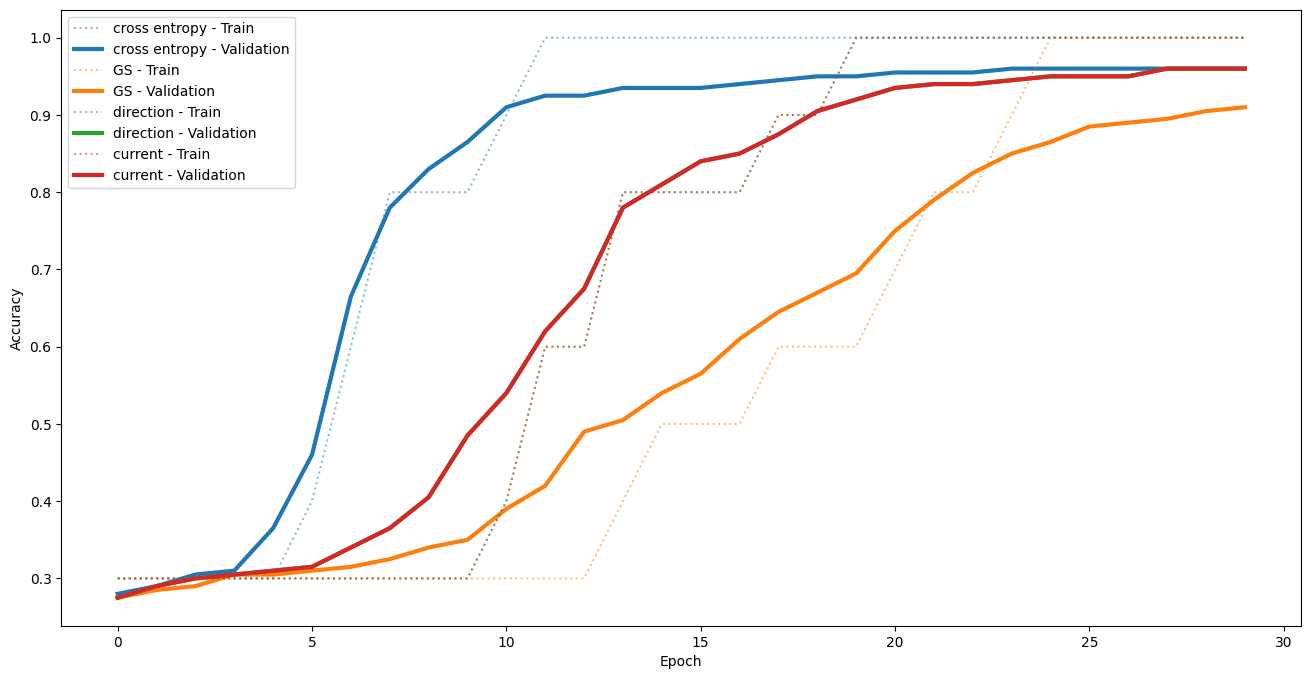

(<Figure size 1600x800 with 1 Axes>, <Axes: xlabel='Epoch', ylabel='Accuracy'>)

In [36]:
path ="/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment/Projects/2D_multiclass/test_results"

plot_results([
    "MODEL_ENSEMBLE_6_MultiClassClassifier__OPTIM_adamw__LR_0.01__BATCHSIZE_32__DATA_3Gaussian_filtered__LOSS_multiclass_cross_entropy_alpha_1.0__SIZE10",
    "MODEL_ENSEMBLE_6_MultiClassClassifier__OPTIM_adamw__LR_0.01__BATCHSIZE_32__DATA_3Gaussian_filtered__LOSS_multiclass_gradient_supervision_alpha_1.0__SIZE10",
    "MODEL_ENSEMBLE_6_MultiClassClassifier__OPTIM_adamw__LR_0.01__BATCHSIZE_32__DATA_3Gaussian_filtered__LOSS_multiclass_combined_loss_alpha_1.0__SIZE10",
    output_name
],
labels=['cross entropy','GS','direction','current'],
path=path
)